# CIFR10 CLASSIFIICATION

### 1.iMPORT NECESSARY LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Flatten,Dense
from matplotlib import pyplot as plt

## 2.Data collection

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [5]:
pd.set_option('display.max_columns',30)

In [7]:
pd.DataFrame(x_train[1,1])

,0,1,2
0,140,160,169
1,145,153,154
2,125,125,118
3,124,129,132
4,150,161,173
5,152,164,175
6,174,188,200
7,178,189,196
8,134,139,137
9,110,111,102


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

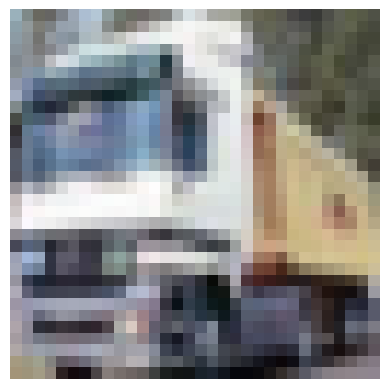

In [13]:
plt.imshow(x_train[1])
plt.axis('off')

### 3.Data preperation - Normalization

In [14]:
x_train.mean(),x_test.mean()

(np.float64(120.70756512369792), np.float64(121.52915475260417))

In [19]:
x_train.std(),x_test.std()

(np.float64(64.1500758911213), np.float64(64.06097012299574))

In [15]:
y_train.mean(),y_test.mean()

(np.float64(4.5), np.float64(4.5))

In [20]:
y_train.std(),y_test.std()

(np.float64(2.8722813232690143), np.float64(2.8722813232690143))

In [16]:
x_train.max(),x_train.min()

(np.uint8(255), np.uint8(0))

In [17]:
x_test.max(),x_test.min()

(np.uint8(255), np.uint8(0))

In [21]:
x_train=x_train/255.0
x_test=x_test/255.0

### 4.Model building

In [25]:
model=Sequential()
model.add(layer=Flatten(input_shape=(32,32,3)))
model.add(Dense( units=300,activation="relu"))
model.add(Dense( units=150,activation="relu"))
model.add(Dense( units=75,activation="relu"))
model.add(Dense( units=10,activation="softmax"))

In [26]:
model.compile( optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['categorical_accuracy'])

### 5.model training

In [27]:
model.fit( x=x_train,y=y_train, batch_size=64,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - categorical_accuracy: 0.1096 - loss: 1.8730 - val_categorical_accuracy: 0.1089 - val_loss: 1.7213
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - categorical_accuracy: 0.0999 - loss: 1.6846 - val_categorical_accuracy: 0.0416 - val_loss: 1.6380
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - categorical_accuracy: 0.0982 - loss: 1.6029 - val_categorical_accuracy: 0.0824 - val_loss: 1.5823
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - categorical_accuracy: 0.0970 - loss: 1.5469 - val_categorical_accuracy: 0.0889 - val_loss: 1.5318
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - categorical_accuracy: 0.0961 - loss: 1.5028 - val_categorical_accuracy: 0.1578 - val_loss: 1.5406
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - categorical_accuracy: 0.0946 - loss: 1.4777 - val_categorical_accuracy: 0.0557 - val_loss: 1.5072
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - categorical_accuracy: 

In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 300)                 │         921,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 150)                 │          45,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 75)                  │          11,325 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │             760 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,937,407 (11.21 MB)

 Trainable params: 979,135 (3.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,958,272 (7.47 MB)

### Manual model prediction

In [29]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [35]:
y_test[2]

array([8], dtype=uint8)

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

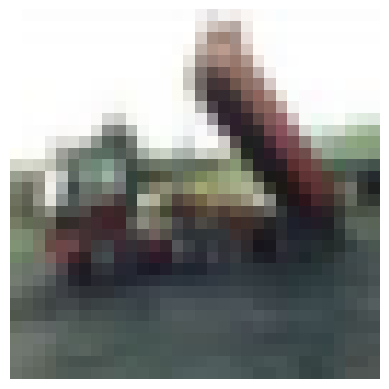

In [36]:
plt.imshow(x_train[2])
plt.axis('off')

In [37]:
model.save("Cifr.h5")

### Last point 